In [15]:
import pandas as pd
import numpy as np
df = pd.read_csv('retail_store_sales.csv')


***TASK 1***

In [16]:
print("FIRST 5 ROWS")
display(df.head())

print("DATASET INFO")
df.info()

print("STATISTICAL SUMMARY")
display(df.describe(include='all'))

FIRST 5 ROWS


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08/04/2024,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23/07/2023,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05/10/2022,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07/05/2022,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02/10/2022,False


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB
STATISTICAL SUMMARY


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
count,12575,12575,12575,11362,11966.000000,11971.000000,11971.000000,12575,12575,12575,8376
unique,12575,25,8,200,NaN,NaN,NaN,3,2,1114,2
top,TXN_2407494,CUST_05,Electric household essentials,Item_2_BEV,NaN,NaN,NaN,Cash,Online,30/05/2022,True
freq,1,544,1591,126,NaN,NaN,NaN,4310,6354,26,4219
mean,NaN,NaN,NaN,NaN,23.365912,5.536380,129.652577,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,10.743519,2.857883,94.750697,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,5.000000,1.000000,5.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,14.000000,3.000000,51.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,23.000000,6.000000,108.500000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,33.500000,8.000000,192.000000,NaN,NaN,NaN,NaN


In [17]:
print("MISSING VALUES PER COLUMN")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
display(missing_df[missing_df['Missing Count'] > 0])

print("DUPLICATE ROWS")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("DATA TYPES")
print(df.dtypes)

print("UNIQUE VALUES (categorical columns)")
for col in ['Category', 'Payment Method', 'Location', 'Discount Applied']:
    print(f"{col}: {df[col].unique()}")

MISSING VALUES PER COLUMN


,Missing Count,Missing %
Item,1213,9.65
Price Per Unit,609,4.84
Quantity,604,4.80
Total Spent,604,4.80
Discount Applied,4199,33.39


DUPLICATE ROWS
Number of duplicate rows: 0
DATA TYPES
Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object
UNIQUE VALUES (categorical columns)
Category: ['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']
Payment Method: ['Digital Wallet' 'Credit Card' 'Cash']
Location: ['Online' 'In-store']
Discount Applied: [True False nan]


In [18]:
before = {
    'Total Rows': len(df),
    'Missing Values': df.isnull().sum().sum(),
    'Duplicate Rows': df.duplicated().sum(),
    'Transaction Date dtype': str(df['Transaction Date'].dtype),
    'Discount Applied dtype': str(df['Discount Applied'].dtype),
    'Columns': len(df.columns)
}
print("before cleaning")
print(before)

before cleaning
{'Total Rows': 12575, 'Missing Values': np.int64(7229), 'Duplicate Rows': np.int64(0), 'Transaction Date dtype': 'object', 'Discount Applied dtype': 'object', 'Columns': 11}


In [19]:
df_clean = df.copy()
# ── Operation 1: Fill missing 'Discount Applied' with False ──────────────
print(f"Missing in 'Discount Applied' before: {df_clean['Discount Applied'].isnull().sum()}")
df_clean['Discount Applied'] = df_clean['Discount Applied'].fillna(False)
print(f"Missing in 'Discount Applied' after:  {df_clean['Discount Applied'].isnull().sum()}")

# ── Operation 2: Fix data types ──────────────────────────────────────────
# Convert Transaction Date to datetime
df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'], dayfirst=True)

# Convert Discount Applied to boolean
df_clean['Discount Applied'] = df_clean['Discount Applied'].astype(bool)

print(f"\nTransaction Date dtype: {df_clean['Transaction Date'].dtype}")
print(f"Discount Applied dtype: {df_clean['Discount Applied'].dtype}")

# ── Operation 3: Drop duplicate rows ────────────────────────────────────
dupes_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"\nDuplicate rows removed: {dupes_before}")

# ── Operation 4: Rename columns (clean up spaces) ───────────────────────
df_clean = df_clean.rename(columns={
    'Price Per Unit': 'Price_Per_Unit',
    'Total Spent': 'Total_Spent',
    'Payment Method': 'Payment_Method',
    'Transaction Date': 'Transaction_Date',
    'Discount Applied': 'Discount_Applied',
    'Customer ID': 'Customer_ID',
    'Transaction ID': 'Transaction_ID'
})
print(f"\nColumns renamed: {list(df_clean.columns)}")

# ── Operation 5: Feature Engineering ────────────────────────────────────
df_clean['Year']  = df_clean['Transaction_Date'].dt.year
df_clean['Month'] = df_clean['Transaction_Date'].dt.month
df_clean['Month_Name'] = df_clean['Transaction_Date'].dt.strftime('%B')

print(f"\n New features added: Year, Month, Month_Name")
print(df_clean[['Transaction_Date', 'Year', 'Month', 'Month_Name']].head())

Missing in 'Discount Applied' before: 4199
Missing in 'Discount Applied' after:  0

Transaction Date dtype: datetime64[ns]
Discount Applied dtype: bool

Duplicate rows removed: 0

Columns renamed: ['Transaction_ID', 'Customer_ID', 'Category', 'Item', 'Price_Per_Unit', 'Quantity', 'Total_Spent', 'Payment_Method', 'Location', 'Transaction_Date', 'Discount_Applied']


/tmp/ipykernel_2365/2549513332.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Discount Applied'] = df_clean['Discount Applied'].fillna(False)



 New features added: Year, Month, Month_Name
  Transaction_Date  Year  Month Month_Name
0       2024-04-08  2024      4      April
1       2023-07-23  2023      7       July
2       2022-10-05  2022     10    October
3       2022-05-07  2022      5        May
4       2022-10-02  2022     10    October


In [20]:
after = {
    'Total Rows': len(df_clean),
    'Missing Values': df_clean.isnull().sum().sum(),
    'Duplicate Rows': df_clean.duplicated().sum(),
    'Transaction Date dtype': str(df_clean['Transaction_Date'].dtype),
    'Discount Applied dtype': str(df_clean['Discount_Applied'].dtype),
    'Columns': len(df_clean.columns)
}

summary = pd.DataFrame({
    'Metric': list(before.keys()),
    'BEFORE': list(before.values()),
    'AFTER': list(after.values())
})

summary['Status'] = summary.apply(
    lambda row: '✅ Fixed' if str(row['BEFORE']) != str(row['AFTER']) else '➖ No Change',
    axis=1
)


print(" DATA QUALITY REPORT — BEFORE vs AFTER")

display(summary)

print(f"\n Cleaning complete! Final dataset shape: {df_clean.shape}")

 DATA QUALITY REPORT — BEFORE vs AFTER


,Metric,BEFORE,AFTER,Status
0,Total Rows,12575,12575,➖ No Change
1,Missing Values,7229,3030,✅ Fixed
2,Duplicate Rows,0,0,➖ No Change
3,Transaction Date dtype,object,datetime64[ns],✅ Fixed
4,Discount Applied dtype,object,bool,✅ Fixed
5,Columns,11,14,✅ Fixed



 Cleaning complete! Final dataset shape: (12575, 14)


***TASK 2***

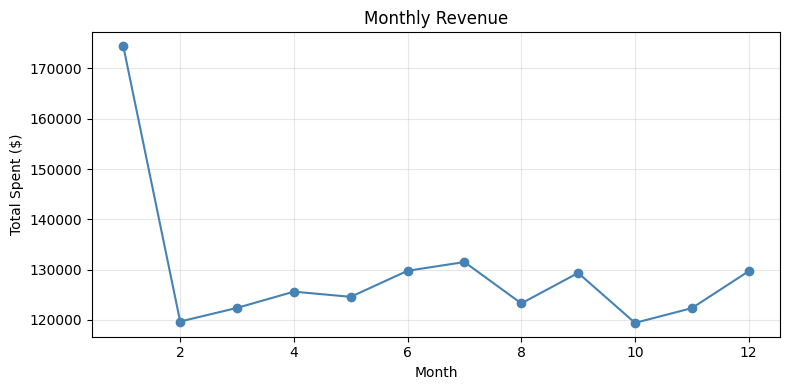

In [23]:
import matplotlib.pyplot as plt
#Line Chart
monthly = df_clean.groupby('Month')['Total_Spent'].sum()

plt.figure(figsize=(8, 4))
plt.plot(monthly.index, monthly.values, color='steelblue', marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Spent ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

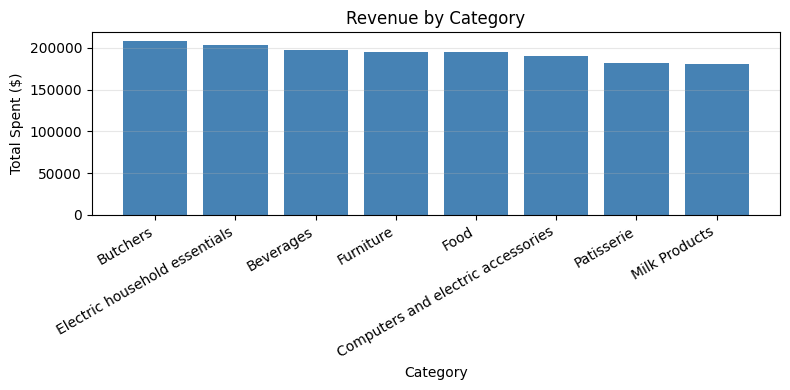

In [24]:
#Bar Chart
cat = df_clean.groupby('Category')['Total_Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(cat.index, cat.values, color='steelblue')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Spent ($)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

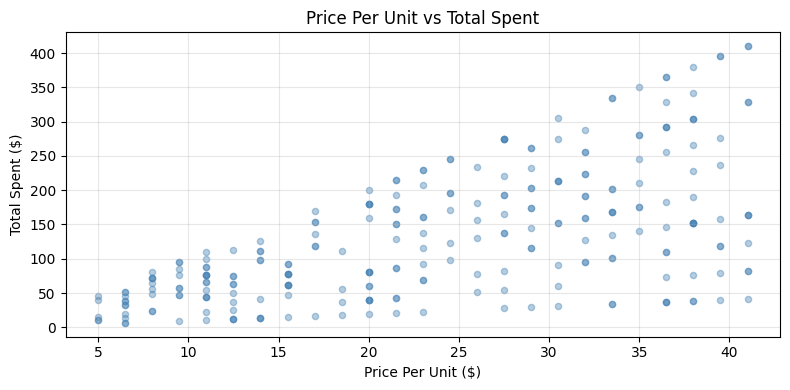

In [25]:
#Scatter Plot
sample = df_clean.sample(300, random_state=42)

plt.figure(figsize=(8, 4))
plt.scatter(sample['Price_Per_Unit'], sample['Total_Spent'], alpha=0.4, color='steelblue', s=20)
plt.title('Price Per Unit vs Total Spent')
plt.xlabel('Price Per Unit ($)')
plt.ylabel('Total Spent ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

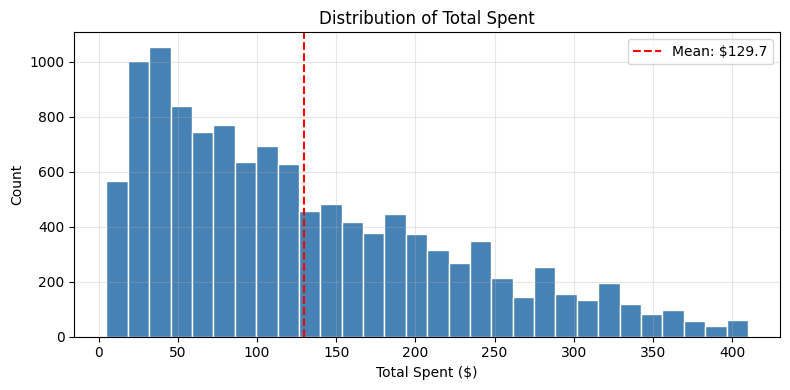

In [26]:
#Histogram
plt.figure(figsize=(8, 4))
plt.hist(df_clean['Total_Spent'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(df_clean['Total_Spent'].mean(), color='red', linestyle='--', label=f"Mean: ${df_clean['Total_Spent'].mean():.1f}")
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent ($)')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

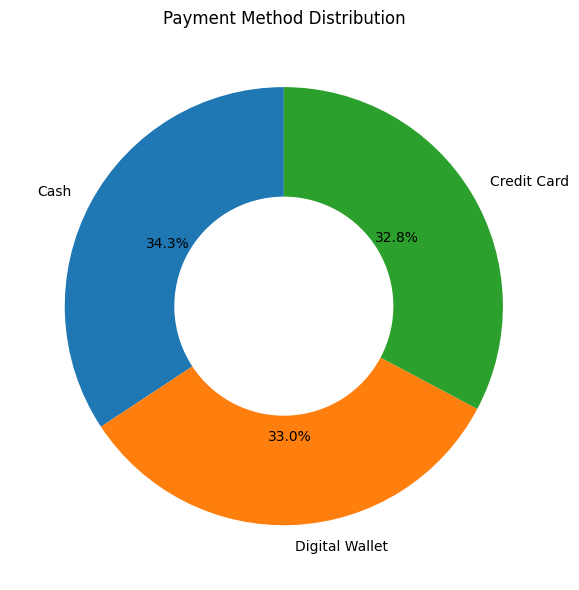

In [27]:
#Donut Chart
payment = df_clean['Payment_Method'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(payment.values, labels=payment.index, autopct='%1.1f%%',
        wedgeprops=dict(width=0.5), startangle=90)
plt.title('Payment Method Distribution')
plt.tight_layout()
plt.show()

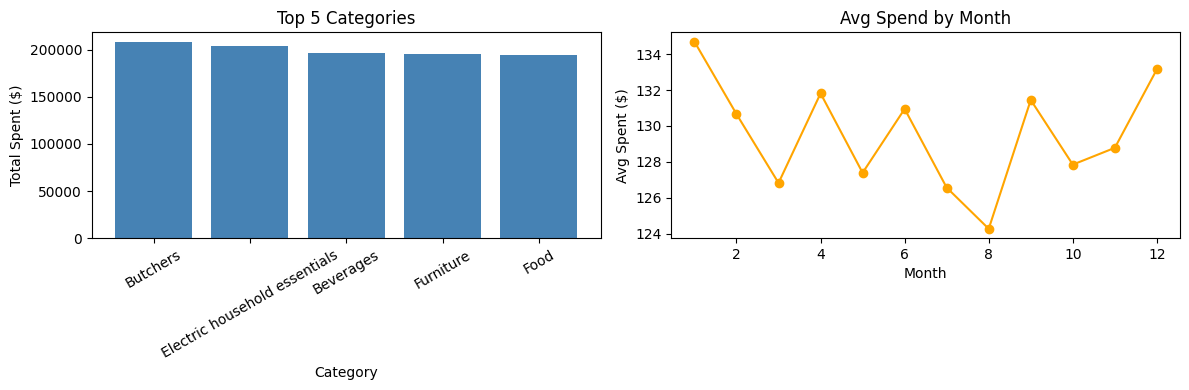

In [28]:
#Subplot (Bar + Line combined)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar
top5 = df_clean.groupby('Category')['Total_Spent'].sum().nlargest(5)
ax1.bar(top5.index, top5.values, color='steelblue')
ax1.set_title('Top 5 Categories')
ax1.set_xlabel('Category')
ax1.set_ylabel('Total Spent ($)')
ax1.tick_params(axis='x', rotation=30)

# Line
avg_month = df_clean.groupby('Month')['Total_Spent'].mean()
ax2.plot(avg_month.index, avg_month.values, color='orange', marker='o')
ax2.set_title('Avg Spend by Month')
ax2.set_xlabel('Month')
ax2.set_ylabel('Avg Spent ($)')

plt.tight_layout()
plt.show()

***Task 3***

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

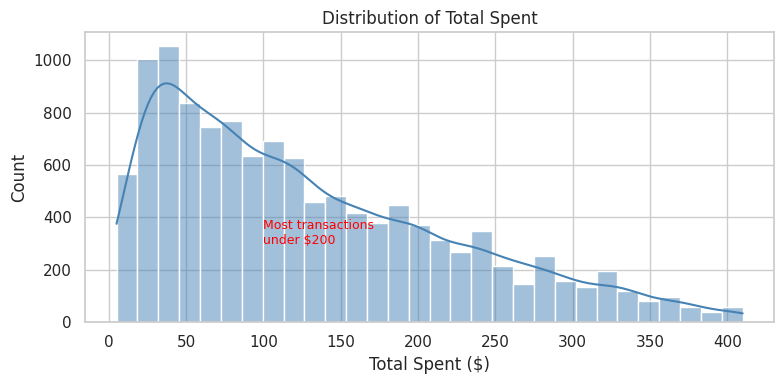

In [32]:
#Distribution Plot: histplot
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['Total_Spent'], bins=30, kde=True, color='steelblue')

plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent ($)')
plt.ylabel('Count')
plt.annotate('Most transactions\nunder $200', xy=(100, 300), fontsize=9, color='red')

plt.tight_layout()
plt.show()

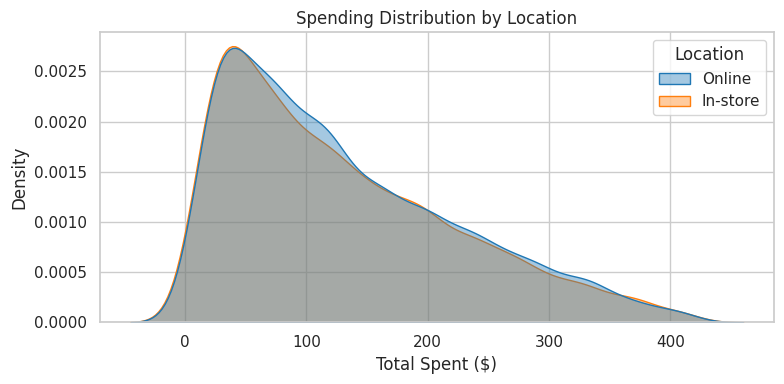

In [33]:
#Distribution Plot: kdeplot by Location
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_clean, x='Total_Spent', hue='Location', fill=True, alpha=0.4)

plt.title('Spending Distribution by Location')
plt.xlabel('Total Spent ($)')
plt.ylabel('Density')
plt.annotate('Similar spend pattern\nacross locations', xy=(300, 0.003), fontsize=9, color='gray')

plt.tight_layout()
plt.show()

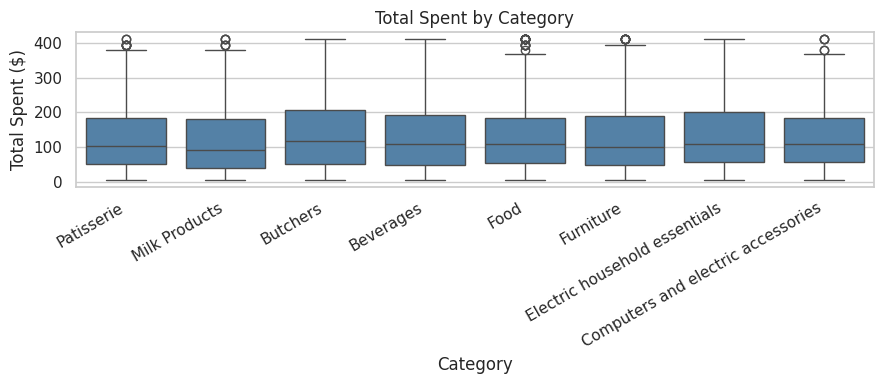

In [34]:
# Categorical Plot: boxplot
plt.figure(figsize=(9, 4))
sns.boxplot(data=df_clean, x='Category', y='Total_Spent', color='steelblue')

plt.title('Total Spent by Category')
plt.xlabel('Category')
plt.ylabel('Total Spent ($)')
plt.xticks(rotation=30, ha='right')
plt.annotate('Outliers present\nin most categories', xy=(0, 450), fontsize=9, color='red')

plt.tight_layout()
plt.show()

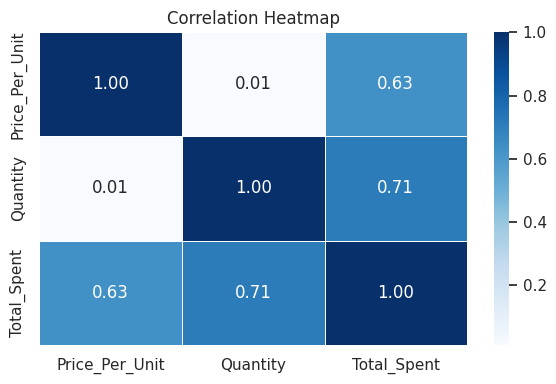

In [35]:
#Relationship Plot: heatmap (Correlation)
plt.figure(figsize=(6, 4))
corr = df_clean[['Price_Per_Unit', 'Quantity', 'Total_Spent']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)

plt.title('Correlation Heatmap')
plt.annotate('Total Spent strongly\ncorrelates with Quantity',
             xy=(1, -0.3), fontsize=9, color='red')

plt.tight_layout()
plt.show()

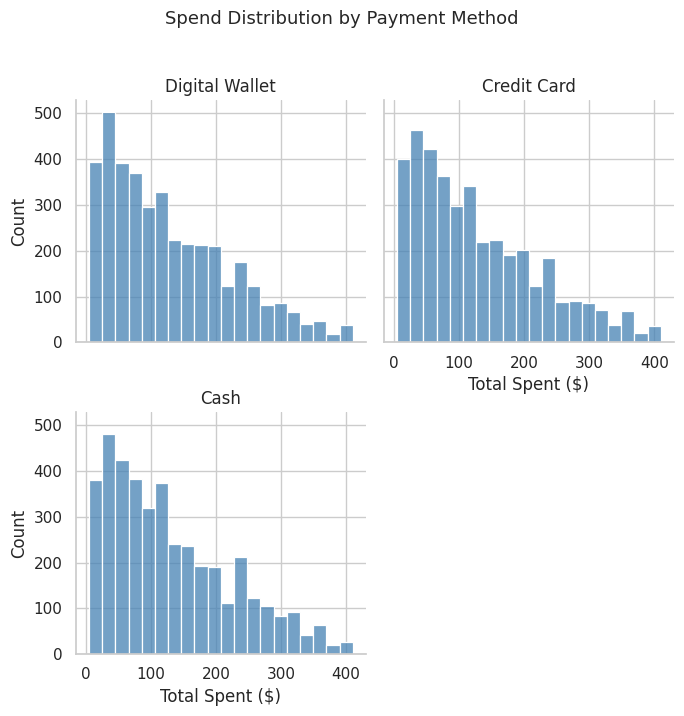

In [36]:
#FacetGrid: Spend Distribution per Payment Method
g = sns.FacetGrid(df_clean, col='Payment_Method', col_wrap=2, height=3.5)
g.map(sns.histplot, 'Total_Spent', bins=20, color='steelblue')

g.set_titles('{col_name}')
g.set_axis_labels('Total Spent ($)', 'Count')
g.figure.suptitle('Spend Distribution by Payment Method', y=1.02, fontsize=13)

plt.tight_layout()
plt.show()

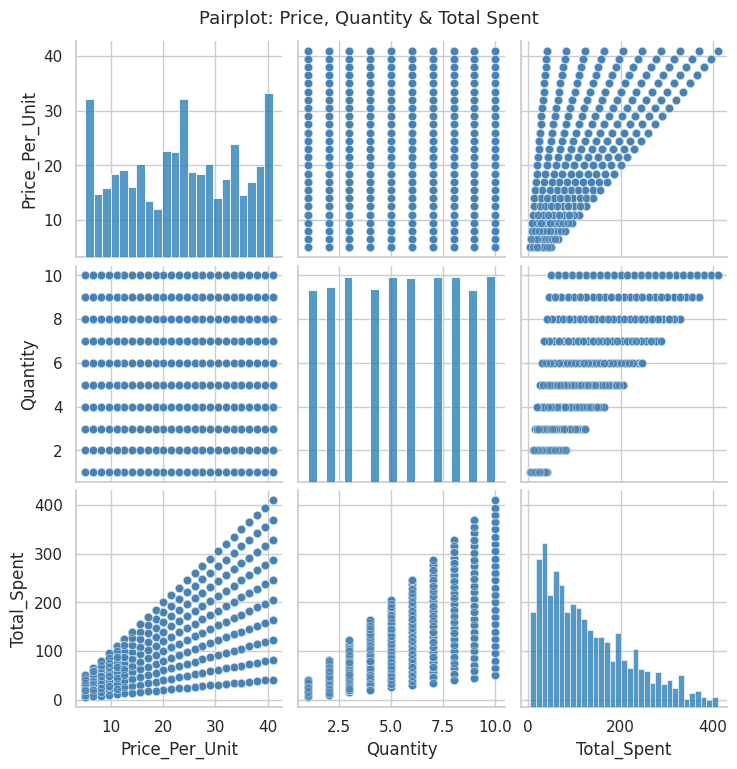

In [37]:
#Pairplot: Multi-variable Relationships
cols = ['Price_Per_Unit', 'Quantity', 'Total_Spent']
sns.pairplot(df_clean[cols], plot_kws={'alpha': 0.3, 'color': 'steelblue'})

plt.suptitle('Pairplot: Price, Quantity & Total Spent', y=1.02, fontsize=13)
plt.show()